In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
from scipy import special as scisp
from scipy.integrate import solve_ivp
from scipy.interpolate import InterpolatedUnivariateSpline,CubicSpline
import scipy.integrate
import scipy.optimize
import multiprocessing
from tqdm import trange
from scipy.optimize import curve_fit
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from scipy.interpolate import interp1d
from matplotlib.ticker import LogLocator, NullFormatter
import sys
from pathlib import Path
# add main_directory/ to the import path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from source.SecludedDM import Cosmology, VectorPortal, BoltzmannSolver, Mpl, find_mXstar, mY_relic

plt.style.use('/home/gab/Desktop/PyCharm_env/mine.mplstyle')
plt.rcParams["axes.axisbelow"] = False

In [2]:
cosmo = Cosmology(gstar_choice="standard", gstarpath="./")
vp_baseline = VectorPortal(mX=5e1, mY=5e1/1.5, gX=2, gY=3, alphaX=1e-3,
                           include_antiparticlesX=True, include_antiparticlesY=False)
solver_baseline = BoltzmannSolver(cosmo, vp_baseline)
sol0= solver_baseline.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=True,
                                                 Gamma_switch_QSSA=5e9, Gamma_switch_full=2e6, cannibal_switch_full=1,
                                                 n_points=500, rtol_value=1e-6, atol_value=1e-18,convergence_threshold=5e-3)

Boltzmann Solver -- QSSA Three-Phase
  mX = 5.00e+01 GeV, mY = 3.33e+01 GeV, r = 1.50
  Phase 1->1.5: Gamma_ann < 5e+09
  Phase 1.5->2: Gamma_ann < 2e+06 AND Gamma_can < 1e+00
  Convergence: dlnxi_NR, thr=0.005
------------------------------------------------------------


Evolving:  10%|█████████▋                                                                                       | 12/120 [00:01<00:07, 15.00it/s]


  -> Phase 1.5 (QSSA) at x = 1.95 (Gamma_ann = 4.6e+09)


Evolving:  23%|██████████████████████▋                                                                          | 28/120 [00:01<00:02, 38.80it/s]


  -> Phase 2 (full) at x = 21.48 (Gamma_ann=1.8e+06, Gamma_can=2.1e+00, muX=0.00)


Evolving:  95%|███████████████████████████████████████████████████████   | 114/120 [00:06<00:00, 17.36it/s, ph=2, x=500, muX=1881.9, dev=4.5e-03]



  Converged (2, dlnxi_NR) at x = 499.5
------------------------------------------------------------
RESULTS:
  x_switch (eq -> QSSA): 1.95
  x_switch (QSSA -> full): 21.48
  x_FO (muX > 0.05): 31.6
  Converged: True at x = 499.5
  YX_relic = 3.369950e-10


In [ ]:
vp_noD1 = VectorPortal(mX=5e1, mY=5e1/1.5, gX=2, gY=3, alphaX=1e-3,
                           include_antiparticlesX=True, include_antiparticlesY=False, Delta1=0)
solver_noD1 = BoltzmannSolver(cosmo, vp_noD1)
sol01= solver_noD1.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=True,
                                                 Gamma_switch_QSSA=5e9, Gamma_switch_full=2e6, cannibal_switch_full=1,
                                                 n_points=500, rtol_value=1e-6, atol_value=1e-18,convergence_threshold=5e-3)

In [ ]:
vp_D3 = VectorPortal(mX=5e1, mY=5e1/1.5, gX=2, gY=3, alphaX=1e-3,
                           include_antiparticlesX=True, include_antiparticlesY=False, Delta1=0, Delta2=0)
solver_D3 = BoltzmannSolver(cosmo, vp_D3)
sol02= solver_D3.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=True,
                                                 Gamma_switch_QSSA=5e9, Gamma_switch_full=2e6, cannibal_switch_full=1,
                                                 n_points=500, rtol_value=1e-6, atol_value=1e-18,convergence_threshold=5e-3)

In [ ]:
vp_noD3 = VectorPortal(mX=5e1, mY=5e1/1.5, gX=2, gY=3, alphaX=1e-3,
                           include_antiparticlesX=True, include_antiparticlesY=False, Delta3=0)
solver_noD3 = BoltzmannSolver(cosmo, vp_noD3)
sol03= solver_noD3.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=True,
                                                 Gamma_switch_QSSA=5e9, Gamma_switch_full=2e6, cannibal_switch_full=1,
                                                 n_points=500, rtol_value=1e-6, atol_value=1e-18,convergence_threshold=5e-3)

In [ ]:
vp_smallD3s = VectorPortal(mX=5e1, mY=5e1/1.5, gX=2, gY=3, alphaX=1e-3,
                         include_antiparticlesX=True, include_antiparticlesY=False,
                         Delta1=1e-3,Delta2=1e-3,Delta3=1e-3)
solver_smallD3s = BoltzmannSolver(cosmo, vp_smallD3s)
sol1 = solver_smallD3s.solve_boltzmann_hybrid(return_bg_ICs=True, verbose=True,n_points=500, rtol_value=1e-6, atol_value=1e-18,convergence_threshold=5e-3,Gamma_switch_Yield=5e9, delta_switch_mu=0.05, delta_eq_threshold=0.02)

In [ ]:
sol12 = solver_smallD3s.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=False,
                                                 Gamma_switch_QSSA=5e9, Gamma_switch_full=1e7, cannibal_switch_full=1e-1,
                                                 n_points=500, rtol_value=1e-6, atol_value=1e-18,convergence_threshold=5e-3)

In [ ]:
vp_largeD3s = VectorPortal(mX=5e1, mY=5e1/1.5, gX=2, gY=3, alphaX=1e-3,
                         include_antiparticlesX=True, include_antiparticlesY=False,
                         Delta1=1e2,Delta2=1e2,Delta3=1e2)
solver_largeD3s = BoltzmannSolver(cosmo, vp_largeD3s)
sol2= solver_largeD3s.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=True,
                                                 Gamma_switch_QSSA=5e9, Gamma_switch_full=1e6, cannibal_switch_full=1e-1,
                                                 n_points=500, rtol_value=1e-6, atol_value=1e-18,convergence_threshold=5e-3)

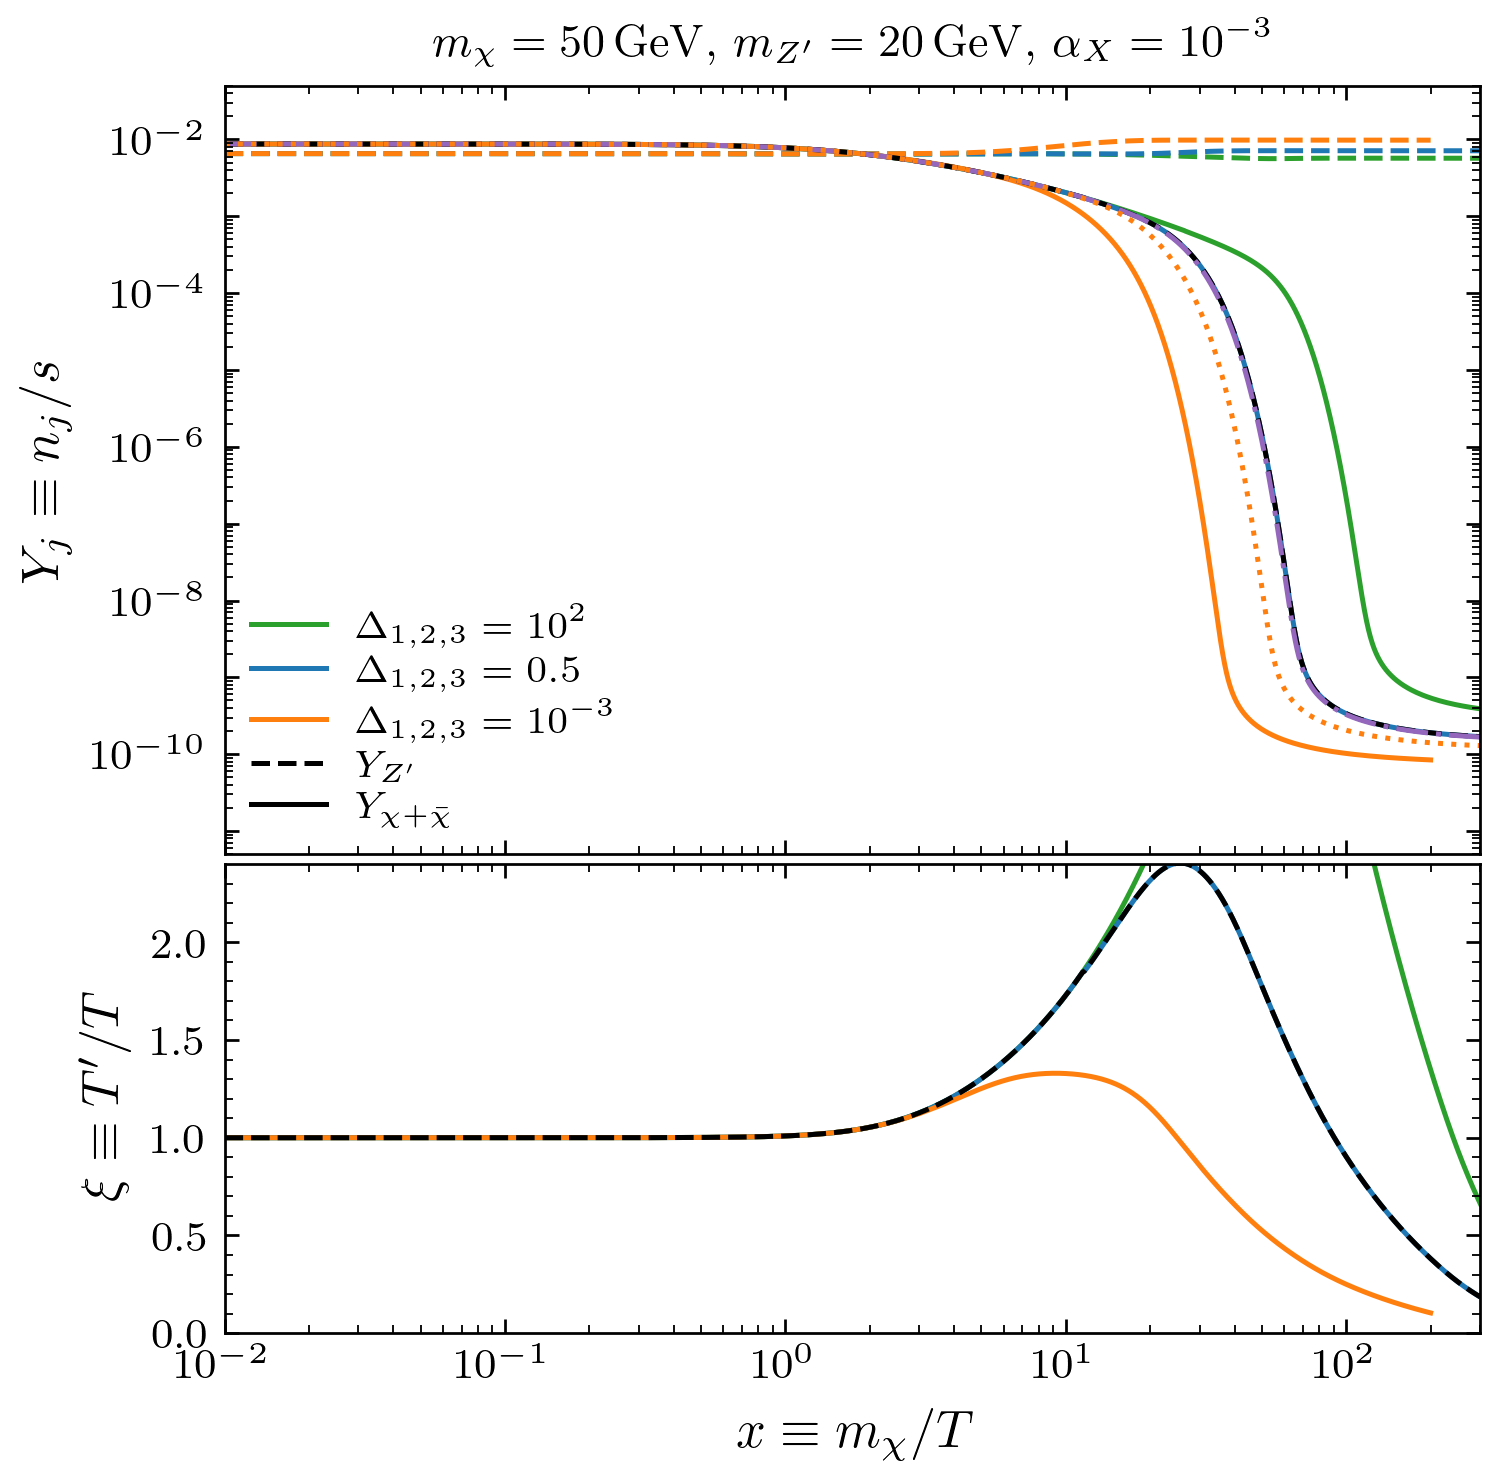

In [38]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
fig1=plt.figure(figsize=(4.5, 4.5))
#fig1=plt.figure(figsize=(7.5, 7.5/1.61803398875*0.5))
gs1 = GridSpec(21,23,figure=fig1)
ax1 = fig1.add_subplot(gs1[:13,:])
ax2 = fig1.add_subplot(gs1[13:,:])
ax1.set_title(r'$m_{\chi}=50\,{\rm GeV},\,m_{Z^\prime}=20\,{\rm GeV},\, \alpha_X=10^{-3}$',fontsize=9)
ax1.plot(sol2['x'],sol2['YX'],lw=1,c=cs[4],ls='-',label=r'$\Delta_{1,2,3}=10^{2}$')
ax1.plot(sol2['x'],sol2['YY'],lw=1,c=cs[4],ls='--')
ax1.plot(sol0['x'],sol0['YX'],lw=1,c=cs[0],label=r'$\Delta_{1,2,3}=0.5$')
ax1.plot(sol0['x'],sol0['YY'],lw=1,c=cs[0],ls='--')
ax1.plot(sol1['x'],sol1['YX'],lw=1,c=cs[2],ls='-',label=r'$\Delta_{1,2,3}=10^{-3}$')
ax1.plot(sol1['x'],sol1['YY'],lw=1,c=cs[2],ls='--')
ax1.plot(sol01['x'],sol01['YX'],lw=1,c='k',ls='--')
ax1.plot(sol02['x'],sol02['YX'],lw=1,c='tab:purple',ls='-.')
ax1.plot(sol03['x'],sol03['YX'],lw=1,c='tab:orange',ls=':')

ax1.plot(np.NaN,np.NaN,ls='--',c='k',lw=1,label=r'$Y_{Z^\prime}$')
ax1.plot(np.NaN,np.NaN,ls='-',c='k',lw=1,label=r'$Y_{\chi +\bar\chi}$')
ax1.legend()
ax2.plot(sol2['x'],sol2['xi'],lw=1,c=cs[4],ls='-',zorder=1)
ax2.plot(sol0['x'],sol0['xi'],lw=1,c=cs[0],zorder=1)
ax2.plot(sol1['x'],sol1['xi'],lw=1,c=cs[2],ls='-',zorder=1)
ax2.plot(sol01['x'],sol01['xi'],lw=1,c='k',ls='--',zorder=1)
ax1.set_xscale("log")
ax2.set_xscale("log")
ax1.set_yscale("log")
ax1.set_ylabel(r"$Y_{j}\equiv n_j/s$")
ax2.set_ylabel(r"$\xi\equiv T^\prime/T$")
ax2.set_xlabel(r"$x\equiv m_\chi/T$")
ax1.set_ylim(5e-12,5e-2)
ax1.set_xlim(1e-2,3e2)
ax2.set_xlim(1e-2,3e2)
ax1.set_xticklabels([])
ax2.set_ylim(0.,2.4)
ax1.set_yticks([1e-11,1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2])
ax1.set_yticklabels(['',r'$10^{-10}$','',r'$10^{-8}$','',r'$10^{-6}$','',r'$10^{-4}$','',r'$10^{-2}$'])
ax1.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,.9], numticks=2000))
ax1.yaxis.set_minor_formatter(NullFormatter())
#plt.savefig("../figs/YEvs_mX50_mY20_alphaX1e-3.pdf")
#plt.savefig("../figs/YEvs_mX50_mY20_alphaX1e-3.png")
plt.show()
plt.close()

In [4]:
alphaXv=1e-3
rv=1.5
cosmo = Cosmology(gstar_choice="standard", gstarpath="./")
model_factory = lambda mX, mY: VectorPortal(mX=mX, mY=mY, gX=2, gY=3, alphaX=alphaXv,
                                            Delta1=.5, Delta2=.5, Delta3=.5,
                                             include_antiparticlesX=True, include_antiparticlesY=False)
res = find_mXstar(cosmo, model_factory, r=rv, verbose=True,
                  solver_kw=dict(convergence_mode="dlnxi_NR", convergence_threshold=1e-2,
                                 cannibal_switch_full=1e-1),
                  delta_S=5e-4)
print(res['mXstar'], res['epsX_min'])

find_mXstar  (r=1.50)
  mX_est = 5.78e+01 GeV  bracket = [5.78e+00, 2.89e+02]
------------------------------------------------------------
  lo: mX=5.78e+00 -> mX*YX=1.11e-10
  hi: mX=2.89e+02 -> mX*YX=6.51e-08
  guess: mX = 1.3438e+01
  refine: mX=6.7191e+00 -> mX*YX=1.4459e-10
  refine: mX=9.5023e+00 -> mX*YX=2.6584e-10
  refine: mX=1.3438e+01 -> mX*YX=4.7905e-10
  refine: mX=1.9005e+01 -> mX*YX=8.6877e-10
  refine: mX=2.6877e+01 -> mX*YX=9.0717e-10
  => mX* = 1.2738e+01 GeV  mY* = 8.4918e+00 GeV  Och2 = 0.120000
  => epsX_min = 5.1443e-09  (dS/S < 0.0005)  SRatio_plateau = 1.8101
12.737684630176782 5.144338971971041e-09


In [ ]:
factory_smallD3s = lambda mX, mY: VectorPortal(mX=mX, mY=mY, gX=2, gY=3, alphaX=alphaXv,
                                                include_antiparticlesX=True, include_antiparticlesY=False,
                                                Delta1=1e-3, Delta2=1e-3, Delta3=1e-3)
res_smallD3s = find_mXstar(cosmo, factory_smallD3s, r=rv, verbose=True,
                           solver_kw=dict(convergence_mode="dlnxi_NR", convergence_threshold=1e-2,
                                          cannibal_switch_full=5e-2))
print(res_smallD3s['mXstar'], res_smallD3s['epsX_min'])

In [ ]:
factory_largeD3s = lambda mX, mY: VectorPortal(mX=mX, mY=mY, gX=2, gY=3, alphaX=alphaXv,
                                                include_antiparticlesX=True, include_antiparticlesY=False,
                                                Delta1=1e2, Delta2=1e2, Delta3=1e2)
res_largeD3s = find_mXstar(cosmo, factory_largeD3s, r=rv, verbose=True,
                           solver_kw=dict(convergence_mode="dlnxi_NR", convergence_threshold=1e-2,
                                          cannibal_switch_full=1e-1, Gamma_switch_full=1e6))
print(res_largeD3s['mXstar'], res_largeD3s['epsX_min'])

In [ ]:
mXs=np.linspace(res['mXstar']*(1+1e-2),5*res['mXstar'],100)
mYs=mXs/rv
epsXs=np.zeros(len(mXs))
epsXs_bbn=np.zeros(len(mXs))
for i in trange(len(mXs)):
    model = VectorPortal(
        mX=mXs[i],       
        mY=mYs[i],       
        gX=2, gY=3,
        alphaX=alphaXv,
        include_antiparticlesX=True,
        include_antiparticlesY=False,
    )
    solver = BoltzmannSolver(cosmo, model)
    sol0 = solver.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=False,
                                                 Gamma_switch_QSSA=5e9, Gamma_switch_full=2e6, cannibal_switch_full=8e-2,
                                                 n_points=500, rtol_value=1e-6, atol_value=1e-18, convergence_mode= "dlnxi_NR",
                                           convergence_threshold=2e-2)
    epsXs[i]= solver.find_epsilon_DMRelic(sol0['bg_ICs'],log10eps_range=(-18,-8),root_rtol= 1e-4)
    #print(epsXs[i],mXs[i])
    epsXs_bbn[i]=solver.find_epsilon_BBN_Neff(sol0['bg_ICs'],T_eval=1e-3,log10eps_range=(-15,-9),root_rtol=1e-3)
    del model, solver
data = np.column_stack([mXs, mYs, epsXs, epsXs_bbn])
header = (f"alphaX={alphaXv:.1e}  r={rv}  mXstar={res['mXstar']:.6e}  "
          f"epsX_min={res['epsX_min']:.6e}  SRatio_plateau={res['SRatio_plateau']:.4f}\n"
          f"mX [GeV]    mY [GeV]    epsX_relic    epsX_bbn_Neff")
np.savetxt(f"../output/relic_aX{alphaXv:.0e}_r{rv}.dat", data, header=header, fmt='%.8e')

In [ ]:
mXs_=np.linspace(res_largeD3s['mXstar']*(1+1e-2),5*res_largeD3s['mXstar'],100)
mYs=mXs/rv
epsXs=np.zeros(len(mXs))
epsXs_bbn=np.zeros(len(mXs))
for i in trange(len(mXs)):
    model = VectorPortal(
        mX=mXs[i],       
        mY=mYs[i],       
        gX=2, gY=3,
        alphaX=alphaXv,
        include_antiparticlesX=True,
        include_antiparticlesY=False,
        Delta1=1e2,Delta2=1e2,Delta3=1e2,
    )
    solver = BoltzmannSolver(cosmo, model)
    sol0 = solver.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=False,
                                                 Gamma_switch_QSSA=5e9, Gamma_switch_full=2e6, cannibal_switch_full=1e-1,
                                                 n_points=500, rtol_value=1e-6, atol_value=1e-18, convergence_mode= "dlnxi_NR",
                                           convergence_threshold=1e-2)
    epsXs[i]= solver.find_epsilon_DMRelic(sol0['bg_ICs'],log10eps_range=(-18,-8),root_rtol= 1e-4)
    epsXs_bbn[i]=solver.find_epsilon_BBN_Neff(sol0['bg_ICs'],T_eval=1e-3,log10eps_range=(-15,-9),root_rtol=1e-3)
    del model, solver
data = np.column_stack([mXs, mYs, epsXs, epsXs_bbn])
header = (f"alphaX={alphaXv:.1e}  r={rv}  mXstar={res_largeD3s['mXstar']:.6e}  "
          f"epsX_min={res_largeD3s['epsX_min']:.6e}  SRatio_plateau={res_largeD3s['SRatio_plateau']:.4f}\n"
          f"mX [GeV]    mY [GeV]    epsX_relic    epsX_bbn_Neff")
np.savetxt(f"../output/relic_aX{alphaXv:.0e}_r{rv}_D123_1e2.dat", data, header=header, fmt='%.8e')

In [146]:
def load_relic(fname):
    with open(fname) as f:
        params = dict(s.split('=') for s in f.readline().lstrip('# ').split())
    mXs, mYs, epsXs, epsXs_bbn = np.loadtxt(fname).T
    return {**{k: float(v) for k, v in params.items()},
            'mXs': mXs, 'mYs': mYs, 'epsXs': epsXs, 'epsXs_bbn': epsXs_bbn}
    
dat1 = load_relic("../output/relic_aX1e-03_r1.5.dat")
dat2 = load_relic("../output/relic_aX1e-03_r1.5_D123_1e2.dat")
dat3 = load_relic("../output/relic_aX1e-03_r1.5_D123_1e-2.dat")
mXs1, mYs1, epsXs1, epsXs_bbn1 = dat1['mXs'],dat1['mYs'],dat1['epsXs'],dat1['epsXs_bbn']
mXs1  = np.concatenate([[dat1['mXstar'], dat1['mXstar']*(1+1e-6)], mXs1])
epsXs1 = np.concatenate([[1e-4, dat1['epsX_min']],    epsXs1])
mXs2, mYs2, epsXs2, epsXs_bbn1 = dat2['mXs'],dat2['mYs'],dat2['epsXs'],dat2['epsXs_bbn']
mXs2  = np.concatenate([[dat2['mXstar'], dat2['mXstar']*(1+1e-6)], mXs2])
epsXs2 = np.concatenate([[1e-4, dat2['epsX_min']],    epsXs2])
mXs3, mYs3, epsXs3, epsXs_bbn1 = dat3['mXs'],dat3['mYs'],dat3['epsXs'],dat3['epsXs_bbn']
mXs3  = np.concatenate([[dat3['mXstar'], dat3['mXstar']*(1+1e-6)], mXs3])
epsXs3 = np.concatenate([[1e-4, dat3['epsX_min']],    epsXs3])

In [147]:
bbn_bound=interp1d(mXs1[2:],epsXs_bbn1, kind="linear", fill_value="extrapolate", bounds_error=False)
mXs_bbn=np.concatenate([[0.9*mXs2[0]],mXs2])

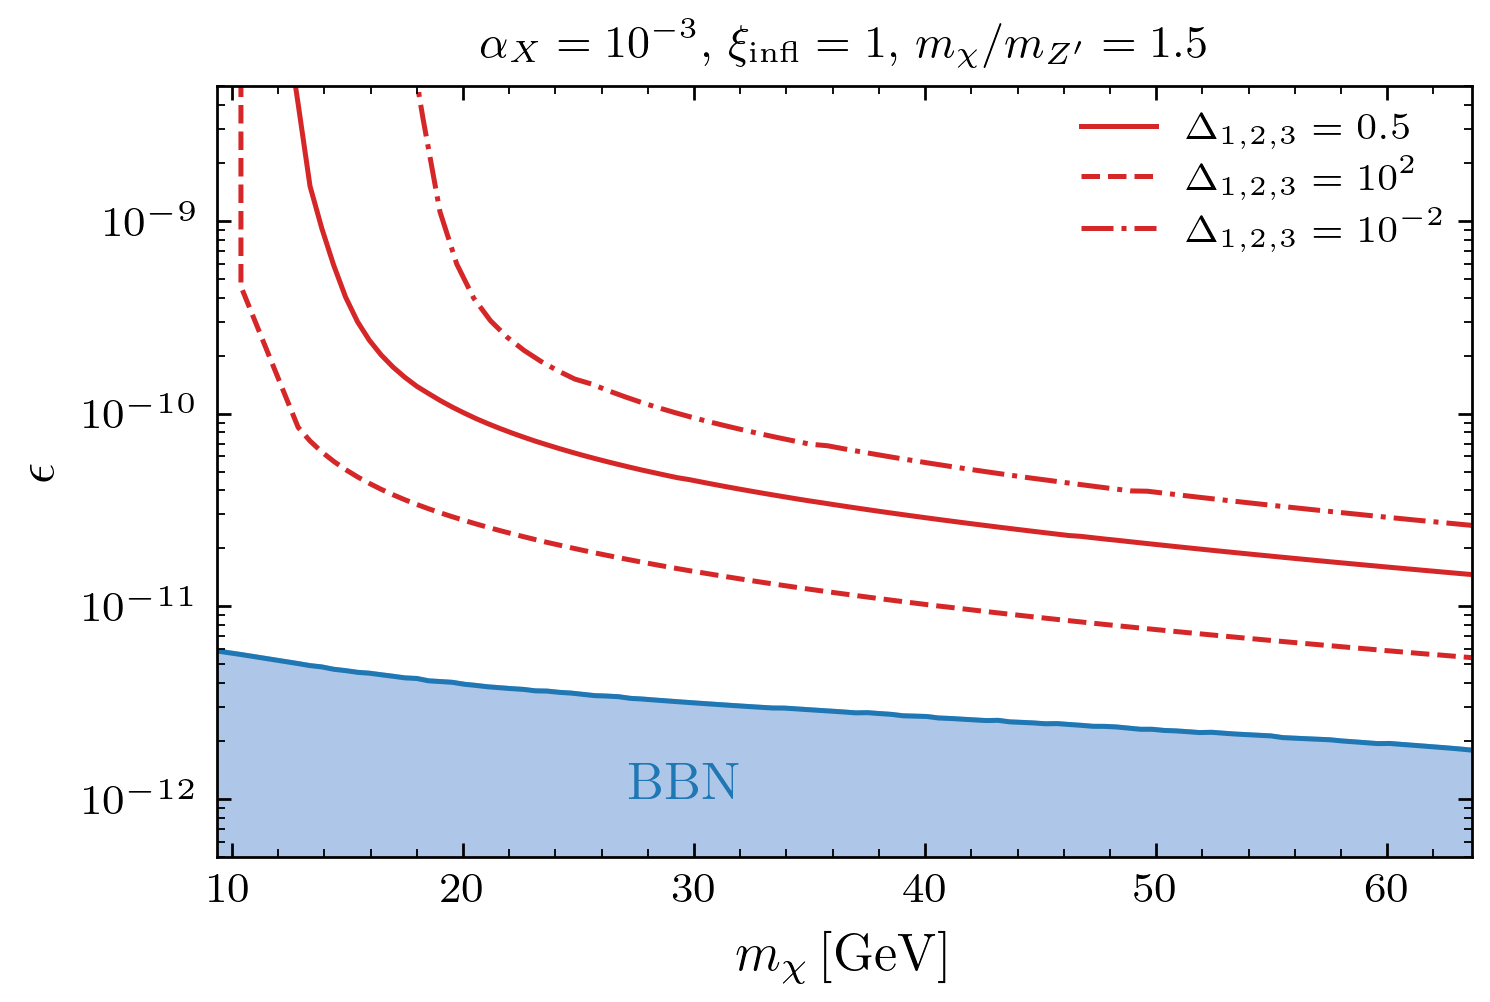

In [149]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
plt.plot(mXs1,epsXs1,lw=1,c=cs[6],label=r'$\Delta_{1,2,3}=0.5$')
plt.plot(mXs2,epsXs2,lw=1,c=cs[6],ls='--',label=r'$\Delta_{1,2,3}=10^{2}$')
plt.plot(mXs3,epsXs3,lw=1,c=cs[6],ls='-.',label=r'$\Delta_{1,2,3}=10^{-2}$')
plt.fill_between(mXs_bbn,0, bbn_bound(mXs_bbn),lw=1,color=cs[1],alpha=1)
plt.plot(mXs_bbn,bbn_bound(mXs_bbn),lw=1,color=cs[0],ls='-')
plt.legend()
plt.yscale("log")
plt.ylabel("$\epsilon$")
plt.ylim(5e-13,5e-9)
plt.title(r'$\alpha_X=10^{-3},\,\xi_{\rm infl}=1,\,m_\chi/m_{Z^\prime}=1.5$',fontsize=9)
plt.xlim(np.min(mXs2*(1-1e-1)),np.max(mXs2))
plt.text(dat3['mXstar']*1.5,1e-12,r"BBN",color=cs[0])
plt.xlabel(r"$m_\chi\,[{\rm GeV}]$")
plt.savefig("../D123_Impact_aX1e-3_xiInf1_r1.5.png")
plt.savefig("../D123_Impact_aX1e-3_xiInf1_r1.5.pdf")
plt.show()
plt.close()

In [ ]:
factory_infl2 = lambda mX, mY: VectorPortal(mX=mX, mY=mY, gX=2, gY=3, alphaX=alphaXv,
                                             include_antiparticlesX=True, include_antiparticlesY=False,
                                             xi_infl=2)
res_infl2 = find_mXstar(cosmo, factory_infl2, r=rv, verbose=True,
                         solver_kw=dict(convergence_mode="dlnxi_NR", convergence_threshold=1e-2,
                                        cannibal_switch_full=1e-1),
                         delta_S=5e-4)
print(res_infl2['mXstar'], res_infl2['epsX_min'])

In [ ]:
mXs=np.linspace(res_infl2['mXstar']*(1+1e-2),5*res_infl2['mXstar'],100)
mYs=mXs/rv
epsXs=np.zeros(len(mXs))
epsXs_bbn=np.zeros(len(mXs))
for i in trange(len(mXs)):
    model = VectorPortal(
        mX=mXs[i],       
        mY=mYs[i],       
        gX=2, gY=3,
        alphaX=alphaXv,
        include_antiparticlesX=True,
        include_antiparticlesY=False,
        xi_infl=2,
    )
    solver = BoltzmannSolver(cosmo, model)
    sol0 = solver.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=False,
                                                 Gamma_switch_QSSA=5e9, Gamma_switch_full=2e6, cannibal_switch_full=1e-1,
                                                 n_points=500, rtol_value=1e-6, atol_value=1e-18, convergence_mode= "dlnxi_NR",
                                           convergence_threshold=2e-2)
    epsXs[i]= solver.find_epsilon_DMRelic(sol0['bg_ICs'],log10eps_range=(-18,-8),root_rtol= 1e-4)
    epsXs_bbn[i]=solver.find_epsilon_BBN_Neff(sol0['bg_ICs'],T_eval=1e-3,log10eps_range=(-15,-9),root_rtol=1e-3)
    del model, solver
data = np.column_stack([mXs, mYs, epsXs, epsXs_bbn])
header = (f"alphaX={alphaXv:.1e}  r={rv}  mXstar={res_infl2['mXstar']:.6e}  "
          f"epsX_min={res_infl2['epsX_min']:.6e}  SRatio_plateau={res_infl2['SRatio_plateau']:.4f}\n"
          f"mX [GeV]    mY [GeV]    epsX_relic    epsX_bbn_Neff")
np.savetxt(f"../output/relic_aX{alphaXv:.0e}_r{rv}_xiinfl2.dat", data, header=header, fmt='%.8e')

In [ ]:
factory_infl05 = lambda mX, mY: VectorPortal(mX=mX, mY=mY, gX=2, gY=3, alphaX=alphaXv,
                                              include_antiparticlesX=True, include_antiparticlesY=False,
                                              xi_infl=0.5)
res_infl05 = find_mXstar(cosmo, factory_infl05, r=rv, verbose=True,
                          solver_kw=dict(convergence_mode="dlnxi_NR", convergence_threshold=1e-2,
                                         cannibal_switch_full=1e-1),
                          delta_S=5e-4)
print(res_infl05['mXstar'], res_infl05['epsX_min'])

In [ ]:
mXs=np.linspace(res_infl05['mXstar']*(1+1e-2),5*res_infl05['mXstar'],100)
mYs=mXs/rv
epsXs=np.zeros(len(mXs))
epsXs_bbn=np.zeros(len(mXs))
for i in trange(len(mXs)):
    model = VectorPortal(
        mX=mXs[i],       
        mY=mYs[i],       
        gX=2, gY=3,
        alphaX=alphaXv,
        include_antiparticlesX=True,
        include_antiparticlesY=False,
        xi_infl=.5,
    )
    solver = BoltzmannSolver(cosmo, model)
    sol0 = solver.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=False,
                                                 Gamma_switch_QSSA=5e9, Gamma_switch_full=2e6, cannibal_switch_full=1,
                                                 n_points=500, rtol_value=1e-6, atol_value=1e-18, convergence_mode= "dlnxi_NR",
                                           convergence_threshold=2e-2)
    epsXs[i]= solver.find_epsilon_DMRelic(sol0['bg_ICs'],log10eps_range=(-18,-8),root_rtol= 1e-4)
    epsXs_bbn[i]=solver.find_epsilon_BBN_Neff(sol0['bg_ICs'],T_eval=1e-3,log10eps_range=(-15,-9),root_rtol=1e-3)
    del model, solver
data = np.column_stack([mXs, mYs, epsXs, epsXs_bbn])
header = (f"alphaX={alphaXv:.1e}  r={rv}  mXstar={res_infl05['mXstar']:.6e}  "
          f"epsX_min={res_infl05['epsX_min']:.6e}  SRatio_plateau={res_infl05['SRatio_plateau']:.4f}\n"
          f"mX [GeV]    mY [GeV]    epsX_relic    epsX_bbn_Neff")
np.savetxt(f"../output/relic_aX{alphaXv:.0e}_r{rv}_xiinfl05_v2.dat", data, header=header, fmt='%.8e')

In [138]:
dat1 = load_relic("../output/relic_aX1e-03_r1.5.dat")
dat2 = load_relic("../output/relic_aX1e-03_r1.5_xiinfl2.dat")
dat3 = load_relic("../output/relic_aX1e-03_r1.5_xiinfl05_v2.dat")
mXs1, mYs1, epsXs1, epsXs_bbn1 = dat1['mXs'],dat1['mYs'],dat1['epsXs'],dat1['epsXs_bbn']
mXs1  = np.concatenate([[dat1['mXstar'], dat1['mXstar']*(1+1e-6)], mXs1])
epsXs1 = np.concatenate([[1e-4, dat1['epsX_min']],    epsXs1])
mXs2, mYs2, epsXs2, epsXs_bbn1 = dat2['mXs'],dat2['mYs'],dat2['epsXs'],dat2['epsXs_bbn']
mXs2  = np.concatenate([[dat2['mXstar'], dat2['mXstar']*(1+1e-6)], mXs2])
epsXs2 = np.concatenate([[1e-4, dat2['epsX_min']],    epsXs2])
mXs3, mYs3, epsXs3, epsXs_bbn1 = dat3['mXs'],dat3['mYs'],dat3['epsXs'],dat3['epsXs_bbn']
mXs3  = np.concatenate([[dat3['mXstar'], dat3['mXstar']*(1+1e-6)], mXs3])
epsXs3 = np.concatenate([[1e-4, dat3['epsX_min']],    epsXs3])

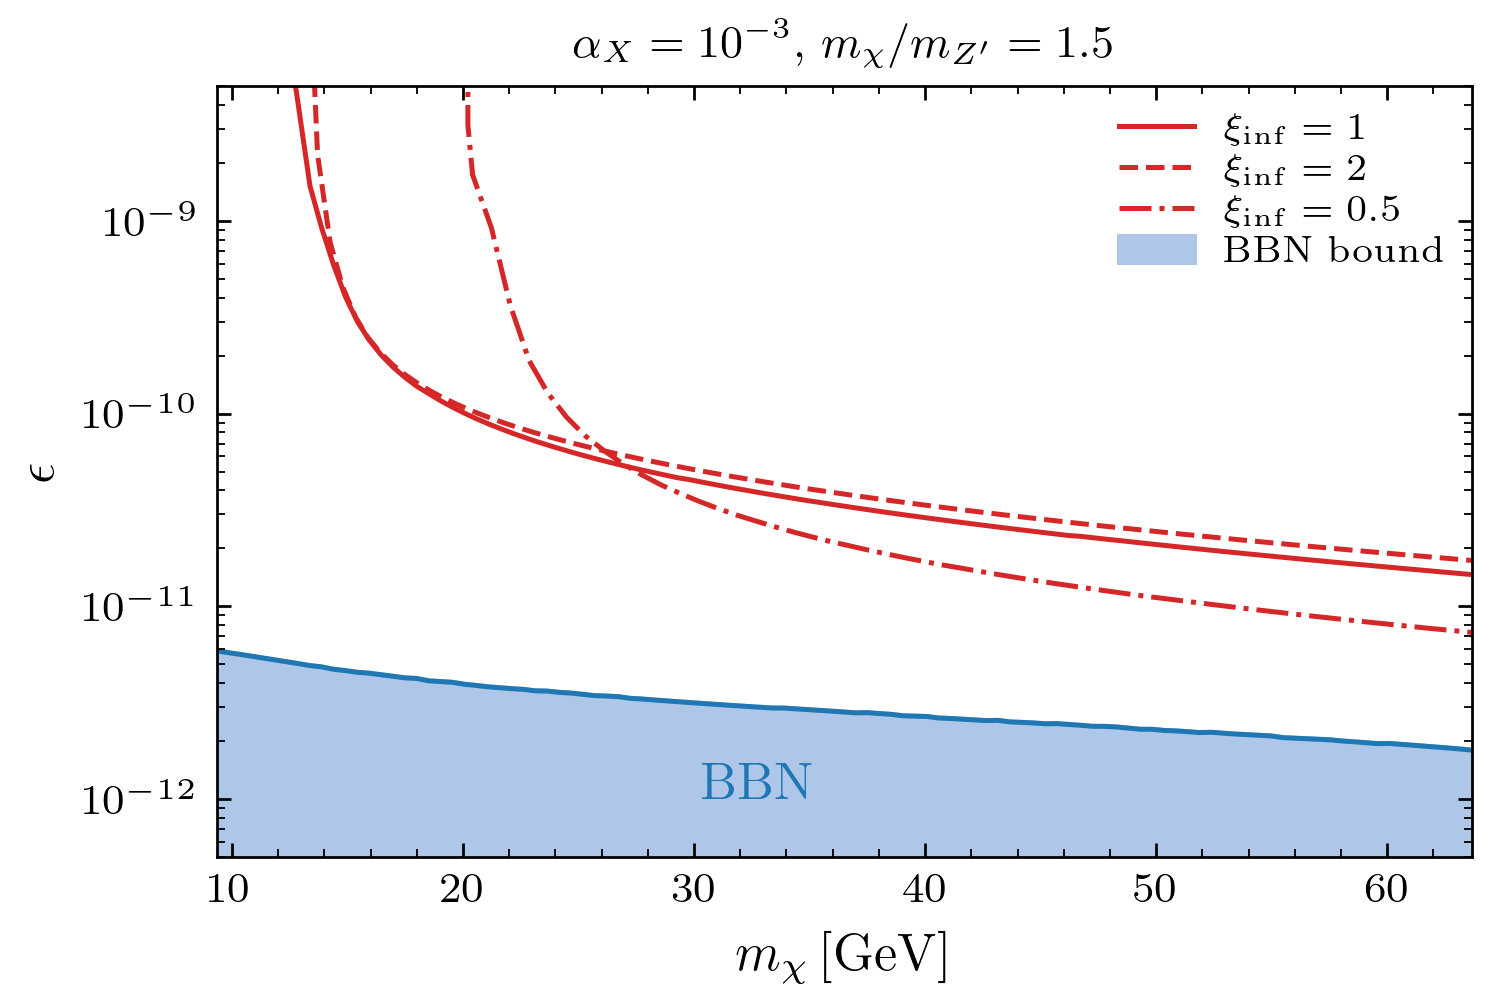

In [145]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
plt.plot(mXs1,epsXs1,lw=1,c=cs[6],label=r'$\xi_{\rm inf}=1$')
plt.plot(mXs2,epsXs2,lw=1,c=cs[6],ls='--',label=r'$\xi_{\rm inf}=2$')
plt.plot(mXs3,epsXs3,lw=1,c=cs[6],ls='-.',label=r'$\xi_{\rm inf}=0.5$')
plt.fill_between(mXs_bbn,0, bbn_bound(mXs_bbn),lw=1,color=cs[1],alpha=1)
plt.plot(mXs_bbn,bbn_bound(mXs_bbn),lw=1,color=cs[0],ls='-')
plt.legend()
plt.yscale("log")
plt.ylabel("$\epsilon$")
plt.ylim(5e-13,5e-9)
plt.title(r'$\alpha_X=10^{-3},\,m_\chi/m_{Z^\prime}=1.5$',fontsize=9)
plt.xlim(np.min(mXs_bbn),np.max(mXs_bbn))
plt.text(dat3['mXstar']*1.5,1e-12,r"BBN",color=cs[0])
plt.xlabel(r"$m_\chi\,[{\rm GeV}]$")
plt.savefig("../figs/xiInfl_impact_aX1e-3_r1.5.png")
plt.savefig("../figs/xiInfl_impact_aX1e-3_r1.5.pdf")
plt.show()
plt.close()

In [ ]:
vp_xiInfl05 = VectorPortal(mX=5e1, mY=2e1, gX=2, gY=3, alphaX=1e-3,
                           include_antiparticlesX=True, include_antiparticlesY=False, xi_infl=0.5)
solver_xiInfl05 = BoltzmannSolver(cosmo, vp_xiInfl05)
sol1= solver_xiInfl05.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=False,
                                                 Gamma_switch_QSSA=5e9, Gamma_switch_full=2e6, cannibal_switch_full=1e-1,
                                                 n_points=500, rtol_value=1e-6, atol_value=1e-18,convergence_threshold=5e-3)

In [ ]:
vp_xiInfl2 = VectorPortal(mX=5e1, mY=2e1, gX=2, gY=3, alphaX=1e-3,
                           include_antiparticlesX=True, include_antiparticlesY=False, xi_infl=2)
solver_xiInfl2 = BoltzmannSolver(cosmo, vp_xiInfl2)
sol2= solver_xiInfl2.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=False,
                                                 Gamma_switch_QSSA=5e9, Gamma_switch_full=2e6, cannibal_switch_full=1e-1,
                                                 n_points=500, rtol_value=1e-6, atol_value=1e-18,convergence_threshold=5e-3)
sol22=solver_xiInfl2.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=True,
                                                 Gamma_switch_QSSA=5e9, Gamma_switch_full=2e6, cannibal_switch_full=5e-1,
                                                 n_points=500, rtol_value=1e-6, atol_value=1e-18,convergence_threshold=5e-3)

#sol22= solver_xiInfl2.solve_boltzmann_hybrid(return_bg_ICs=True, verbose=False,n_points=500, rtol_value=1e-6, atol_value=1e-18,convergence_threshold=5e-3,Gamma_switch_Yield=5e9, delta_switch_mu=0.01, delta_eq_threshold=0.02)

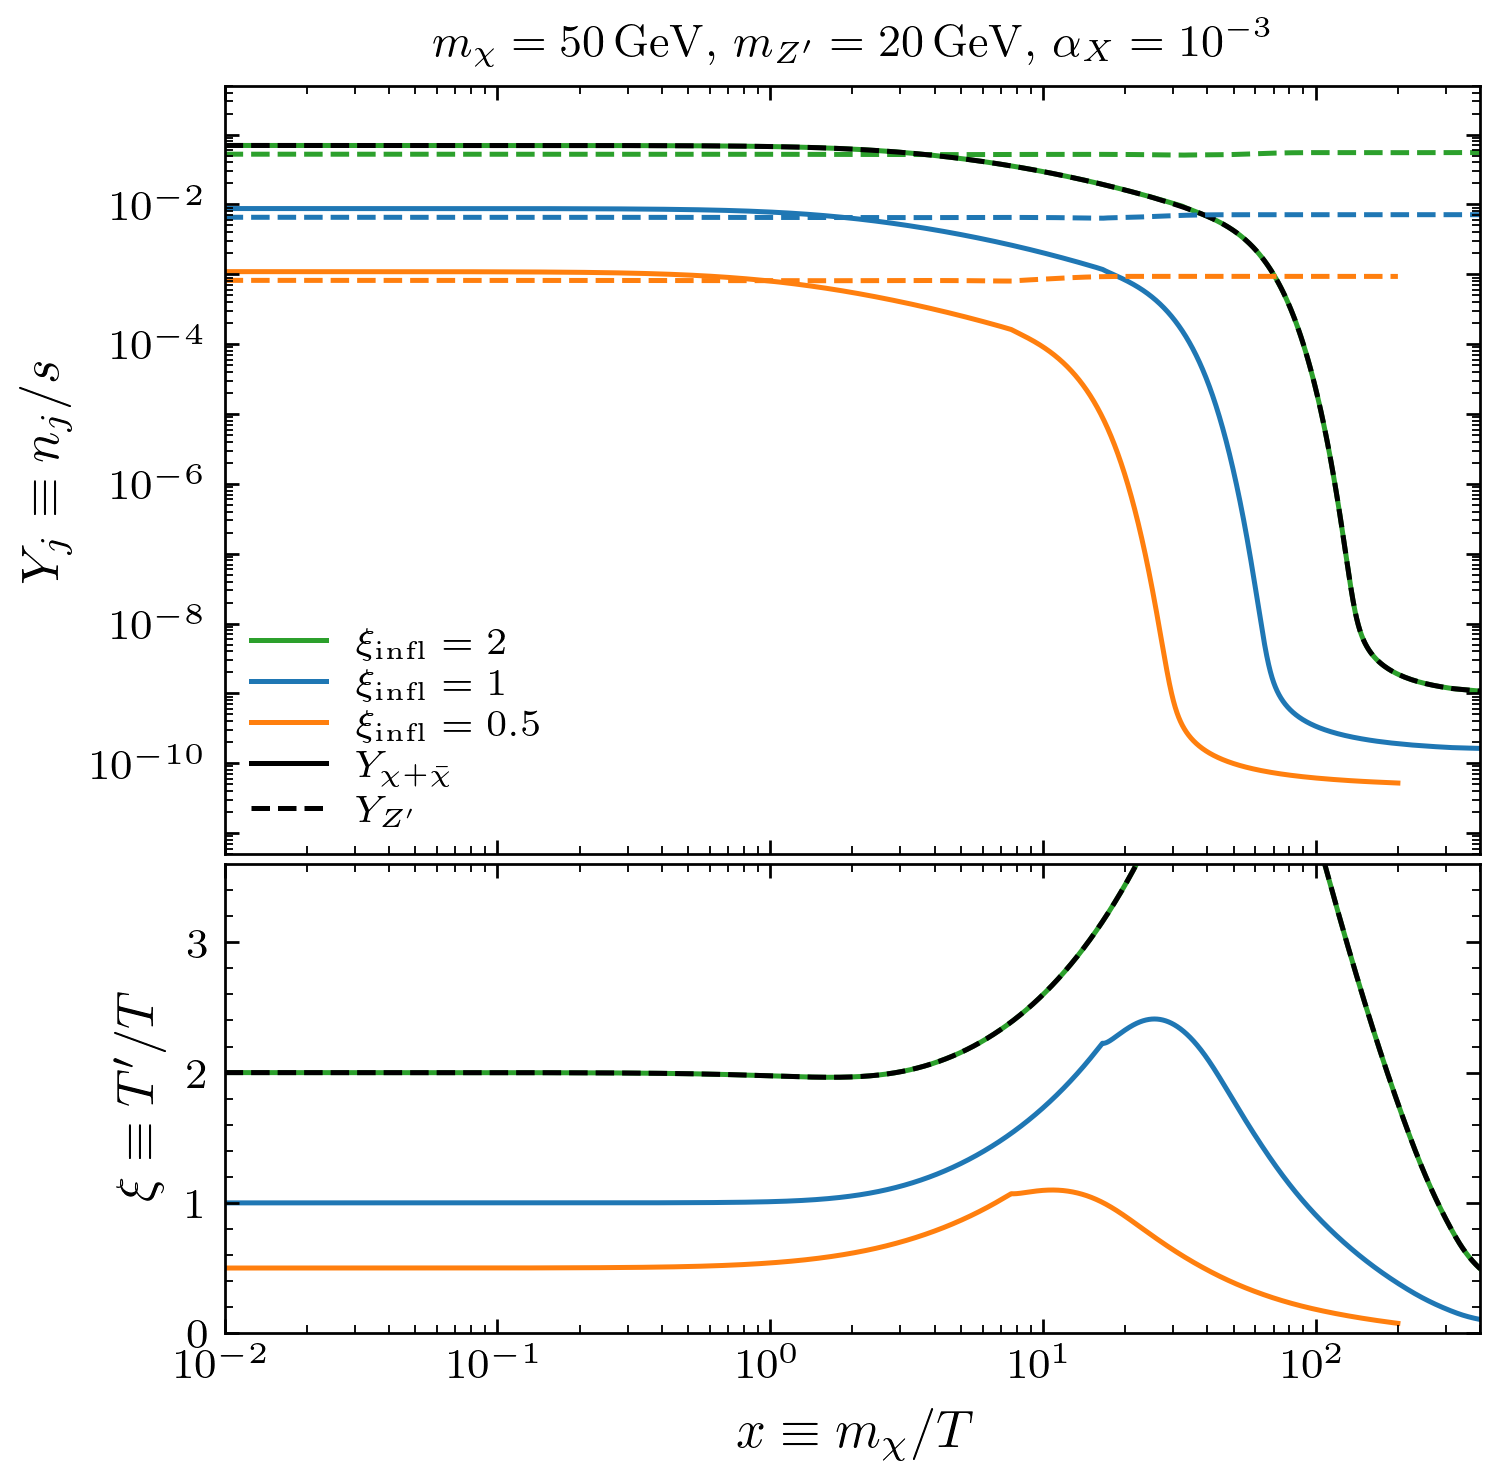

In [118]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
fig1=plt.figure(figsize=(4.5, 4.5))
#fig1=plt.figure(figsize=(7.5, 7.5/1.61803398875*0.5))
gs1 = GridSpec(21,23,figure=fig1)
ax1 = fig1.add_subplot(gs1[:13,:])
ax2 = fig1.add_subplot(gs1[13:,:])
ax1.set_title(r'$m_{\chi}=50\,{\rm GeV},\,m_{Z^\prime}=20\,{\rm GeV},\, \alpha_X=10^{-3}$',fontsize=9)
ax1.plot(sol2['x'],sol2['YX'],lw=1,c=cs[4],ls='-',label=r'$\xi_{\rm infl}=2$')
ax1.plot(sol2['x'],sol2['YY'],lw=1,c=cs[4],ls='--')
ax1.plot(sol22['x'],sol22['YX'],lw=1,c='k',ls='--')
ax1.plot(sol0['x'],sol0['YX'],lw=1,c=cs[0],label=r'$\xi_{\rm infl}=1$')
ax1.plot(sol0['x'],sol0['YY'],lw=1,c=cs[0],ls='--')
ax1.plot(sol1['x'],sol1['YX'],lw=1,c=cs[2],ls='-',label=r'$\xi_{\rm infl}=0.5$')
ax1.plot(sol1['x'],sol1['YY'],lw=1,c=cs[2],ls='--')
ax1.plot(np.NaN,np.NaN,ls='-',c='k',lw=1,label=r'$Y_{\chi +\bar\chi}$')
ax1.plot(np.NaN,np.NaN,ls='--',c='k',lw=1,label=r'$Y_{Z^\prime}$')
ax1.legend()
ax2.plot(sol2['x'],sol2['xi'],lw=1,c=cs[4],ls='-',zorder=1)
ax2.plot(sol0['x'],sol0['xi'],lw=1,c=cs[0],zorder=1)
ax2.plot(sol1['x'],sol1['xi'],lw=1,c=cs[2],ls='-',zorder=1)
ax2.plot(sol22['x'],sol22['xi'],lw=1,c='k',ls='--',zorder=2)

ax1.set_xscale("log")
ax2.set_xscale("log")
ax1.set_yscale("log")
ax1.set_ylabel(r"$Y_{j}\equiv n_j/s$")
ax2.set_ylabel(r"$\xi\equiv T^\prime/T$")
ax2.set_xlabel(r"$x\equiv m_\chi/T$")
ax1.set_ylim(5e-12,5e-1)
ax1.set_xlim(1e-2,4e2)
ax2.set_xlim(1e-2,4e2)
ax1.set_xticklabels([])
ax2.set_ylim(0.,3.6)
ax1.set_yticks([1e-11,1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1])
ax1.set_yticklabels(['',r'$10^{-10}$','',r'$10^{-8}$','',r'$10^{-6}$','',r'$10^{-4}$','',r'$10^{-2}$',''])
ax1.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,.9], numticks=2000))
ax1.yaxis.set_minor_formatter(NullFormatter())
#plt.savefig("../figs/YEvs_mX50_mY20_alphaX1e-3.pdf")
#plt.savefig("../figs/YEvs_mX50_mY20_alphaX1e-3.png")
plt.show()
plt.close()

In [8]:
d16=np.loadtxt("/home/gab/Desktop/JupiterNotebook_projects/secluded_DM/data_2016_paper_Fig2.txt")
rv=20
gXv=2
gYv=3
alphaXv=3e-1

In [ ]:
cosmo = Cosmology(gstar_choice="standard", gstarpath="./")
factory_r20 = lambda mX, mY: VectorPortal(mX=mX, mY=mY, gX=2, gY=3, alphaX=alphaXv,
                                            include_antiparticlesX=True, include_antiparticlesY=False)
res = find_mXstar(cosmo, factory_r20, r=rv, verbose=True,
                  solver_kw=dict(convergence_threshold=1e-2, convergence_mode="dlnxi_NR"))
print(res['mXstar'], res['epsX_min'])

In [ ]:
mXs=np.logspace(np.log10(res['mXstar']*(1+1e-1)),np.log10(d16[:,0][-1]),50)
mYs=mXs/rv
epsXs=np.zeros(len(mXs))
epsXs_bbn=np.zeros(len(mXs))
for i in trange(len(mXs)):
    model = VectorPortal(
        mX=mXs[i],       
        mY=mYs[i],       
        gX=2, gY=3,
        alphaX=alphaXv,
        include_antiparticlesX=True,
        include_antiparticlesY=False,
    )
    solver = BoltzmannSolver(cosmo, model)
    sol0 = solver.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=False,
                                                 Gamma_switch_QSSA=5e9, Gamma_switch_full=2e6, cannibal_switch_full=1, convergence_mode= "dlnxi_NR",
                                                 rtol_value=1e-6, atol_value=1e-18, n_points=500,convergence_threshold=1e-2)
    epsXs[i]= solver.find_epsilon_DMRelic(sol0['bg_ICs'],log10eps_range=(-18,-8),root_rtol= 1e-4)
    epsXs_bbn[i]=solver.find_epsilon_BBN_Neff(sol0['bg_ICs'],T_eval=1e-3,log10eps_range=(-15,-9),root_rtol=1e-3)
    del model, solver

In [ ]:
model = VectorPortal(
        mX=1.1*1e4,       
        mY=1.1*1e4/rv,       
        gX=2, gY=3,
        alphaX=alphaXv,
        include_antiparticlesX=True,
        include_antiparticlesY=False,
    )
solver = BoltzmannSolver(cosmo, model)
sol0 = solver.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=False,
                                                 Gamma_switch_QSSA=5e9, Gamma_switch_full=2e6, cannibal_switch_full=1,
                                                 rtol_value=1e-6, atol_value=1e-10, n_points=500,convergence_threshold=3e-2)
epsXv3= solver.find_epsilon_DMRelic(sol0['bg_ICs'],log10eps_range=(-18,-8),root_rtol= 1e-4)

In [11]:
mX_full  = np.concatenate([[res['mXstar'], res['mXstar']*(1+1e-6)], mXs])
eps_full = np.concatenate([[1e-4, res['epsX_min']],    epsXs])
epsSpl=interp1d(mX_full,eps_full)
mX_fine=np.logspace(np.log10(res['mXstar']),np.log10(d16[:,0][-1]),100)

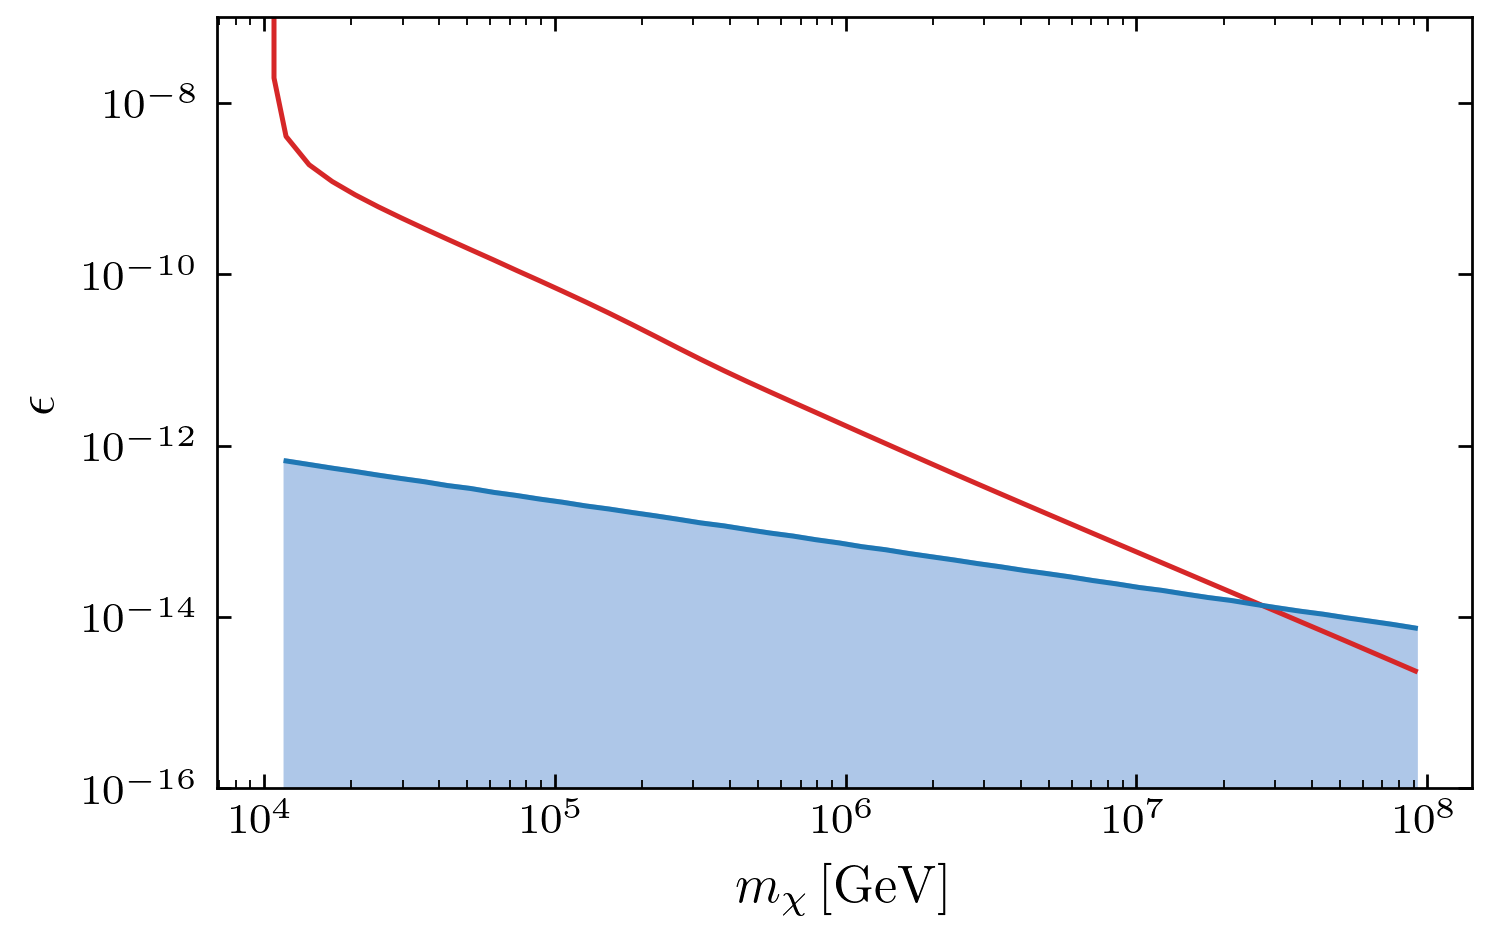

In [12]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
#plt.scatter(1e4,epsXv,marker='d',s=3,color='k')
#plt.scatter(1.1*1e4,epsXv3,marker='d',s=3,color='k')
#plt.scatter(1.05*1e4,epsXv2,marker='d',s=3,color='k')
plt.plot(mX_full,eps_full,lw=1,c=cs[6])
plt.fill_between(mXs,0,epsXs_bbn,lw=1,color=cs[1],label=r'BBN bound',alpha=1)
plt.plot(mXs,epsXs_bbn,lw=1,color=cs[0])

plt.yscale("log")
plt.xscale("log")
plt.ylabel("$\epsilon$")
plt.ylim(1e-16,1e-7)
plt.xlabel(r"$m_\chi\,[{\rm GeV}]$")
plt.show()
plt.close()

In [ ]:
rv = 20
alphaXv = 3e-1
cosmo = Cosmology(gstar_choice="standard", gstarpath="./")

# ── Test 1: Show the xi / zY state at handoff for different settings ──

print("=" * 70)
print("DIAGNOSTIC: handoff state for different convergence settings")
print("=" * 70)

# Pick a fixed mX for testing
mX_test = 1e4  # rough estimate
mY_test = mX_test / rv

model = VectorPortal(mX=mX_test, mY=mY_test, alphaX=alphaXv)
solver = BoltzmannSolver(cosmo, model)

for mode in ['dlnYX', 'dlnxi_NR']:
    for thr in [1e-1, 1e-2, 5e-3]:
        sol = solver.solve_boltzmann_chempot_QSSA(
            Gamma_switch_QSSA=5e9, Gamma_switch_full=2e6, cannibal_switch_full=1,
            rtol_value=1e-6, atol_value=1e-10, n_points=500,
            convergence_mode=mode,
            convergence_threshold=thr,
            return_bg_ICs=True, verbose=False,
        )
        bg = sol['bg_ICs']
        x_end  = bg['x'][-1]
        xi_end = bg['xi'][-1]
        TD_end = bg['TD'][-1]
        zY_end = mY_test / TD_end
        T_end  = bg['T'][-1]

        # Compute rhoY0 as background solver would see it
        s0    = cosmo.s_entropy(T_end)
        rhoY0 = cosmo.Bfac1(mY_test / TD_end, mY_test) * bg['YY'][-1] * s0

        print(f"  {mode:>10s} thr={thr:.0e}: x={x_end:7.1f}  "
              f"xi={xi_end:.6f}  zY={zY_end:6.1f}  "
              f"rhoY0={rhoY0:.4e}  YX={bg['YX'][-1]:.4e}")

        # NOTE: xi_bridge is not implemented — these calls will fail
        # bg_bridged = solver.xi_bridge(bg, zY_target=30.0, verbose=False)
        print()